In [ ]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn import tree
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

In [ ]:
df=pd.read_csv(r'/content/student - Sheet3.csv')
df

,Attendance,Study_hour,Sleep,Interuse,Pass
0,High,High,Good,Low,Yes
1,Low,Low,Poor,High,No
2,High,Medium,Good,Medium,Yes
3,Medium,Low,Poor,High,No
4,High,High,Poor,Low,Yes


In [ ]:
input=df.drop(['Pass'],axis='columns')
target=df['Pass']
target

,Pass
0,Yes
1,No
2,Yes
3,No
4,Yes


In [ ]:
le_Attendance=LabelEncoder()
le_Study_hour=LabelEncoder()
le_Sleep=LabelEncoder()
le_Interuse=LabelEncoder()

print(le_Attendance,le_Study_hour,le_Sleep,le_Interuse)

LabelEncoder() LabelEncoder() LabelEncoder() LabelEncoder()


In [ ]:
input['Attendance_n']=le_Attendance.fit_transform(input['Attendance'])
input['Study_hour_n']=le_Study_hour.fit_transform(input['Study_hour'])
input['Sleep_n']=le_Sleep.fit_transform(input['Sleep'])
input['Interuse_n']=le_Interuse.fit_transform(input['Interuse'])

In [ ]:
input_n=input.drop(['Attendance','Study_hour','Sleep','Interuse'],axis='columns')
input_n

,Attendance_n,Study_hour_n,Sleep_n,Interuse_n
0,0,0,0,1
1,1,1,1,0
2,0,2,0,2
3,2,1,1,0
4,0,0,1,1


In [ ]:
model=tree.DecisionTreeClassifier()
model.fit(input_n,target)

DecisionTreeClassifier()

In [ ]:
#prediction=model.predict([[0,0,0,0]]) -> Yes
#prediction=model.predict([[1,1,1,1]]) -> No
#prediction=model.predict([[2,2,2,2]]) -> No
prediction=model.predict([[0,0,0,1]])
print("Prediction",prediction)

Prediction ['Yes']


In [ ]:
accuracy=model.score(input_n,target)
print("Accuracy",accuracy)


Accuracy 1.0


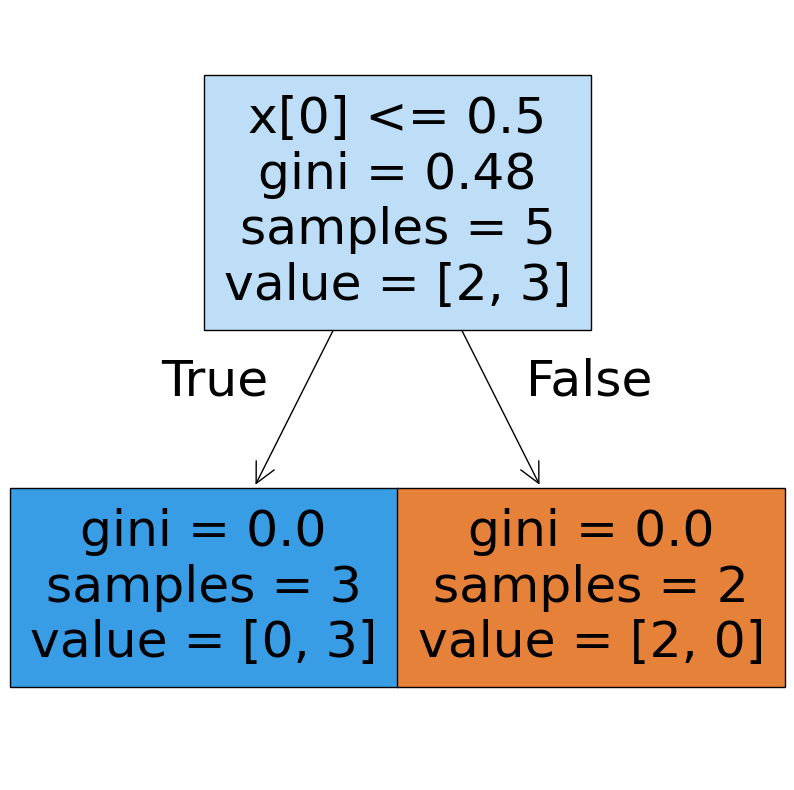

In [ ]:
plt.figure(figsize=(10,10))
tree.plot_tree(model,filled=True)
plt.show()

In [ ]:
import numpy as np
def gini_index(y):
    classes, counts = np.unique(y, return_counts=True)
    probabilities = counts / counts.sum()
    gini = 1 - np.sum(probabilities ** 2)
    return gini
gini = gini_index(df['game'])
print("Gini Index:", gini)

Gini Index: 0.42603550295857995
